In [130]:
!pip install lightgbm
!pip install xgboost

In [131]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [132]:
df = pd.read_csv("diabetes (1).csv")

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# 3. Exploratory Data Analysis (EDA)

In [133]:


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Shape:
(768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.84

In [134]:
#Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


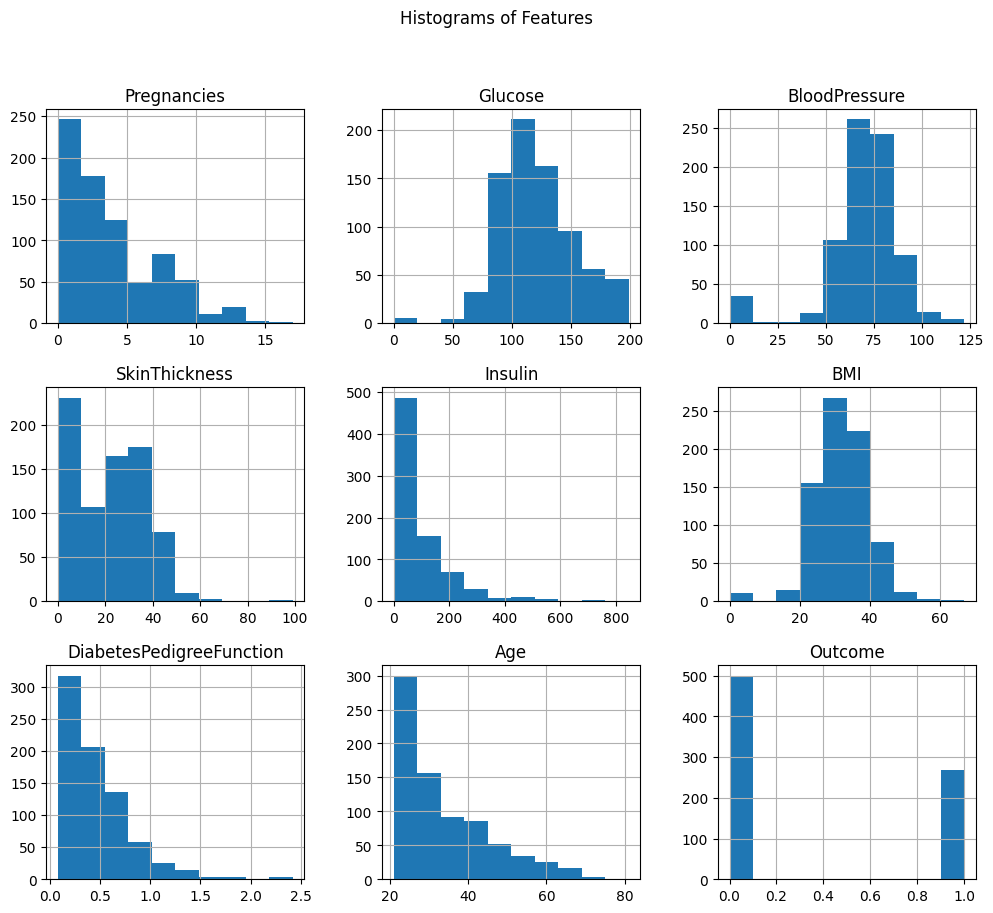

In [135]:
# Histogram
df.hist(figsize=(12,10))
plt.suptitle("Histograms of Features")
plt.show()

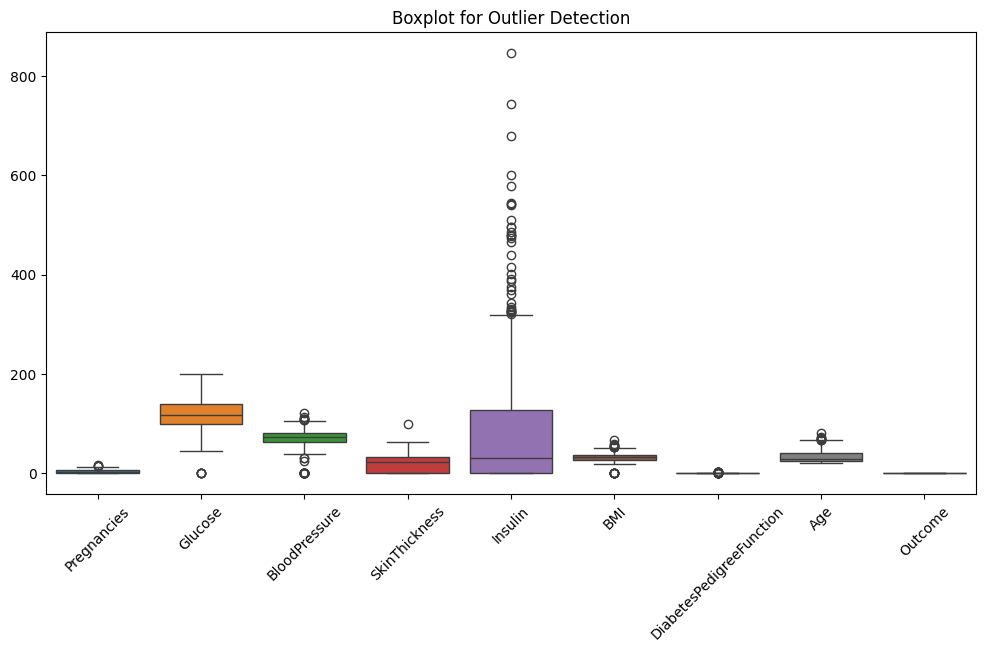

In [136]:
# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

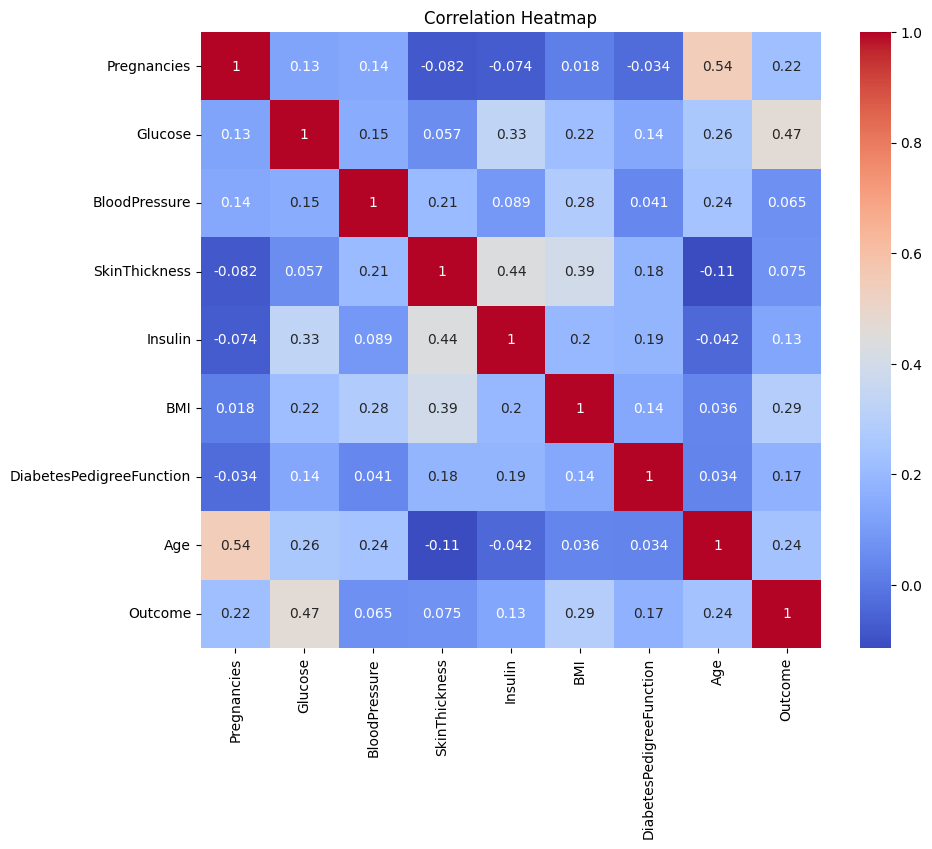

In [137]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

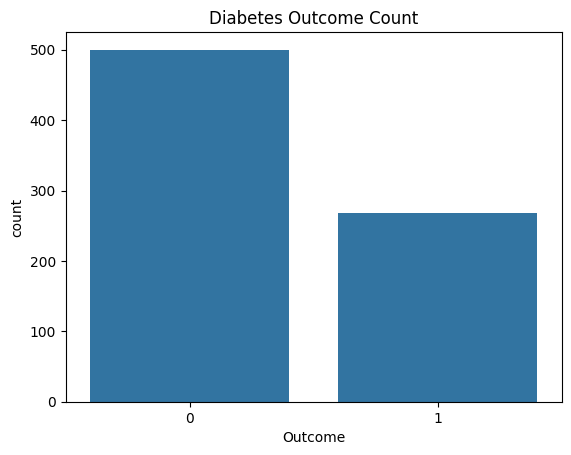

In [138]:
# Outcome Count Plot
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Count")
plt.show()

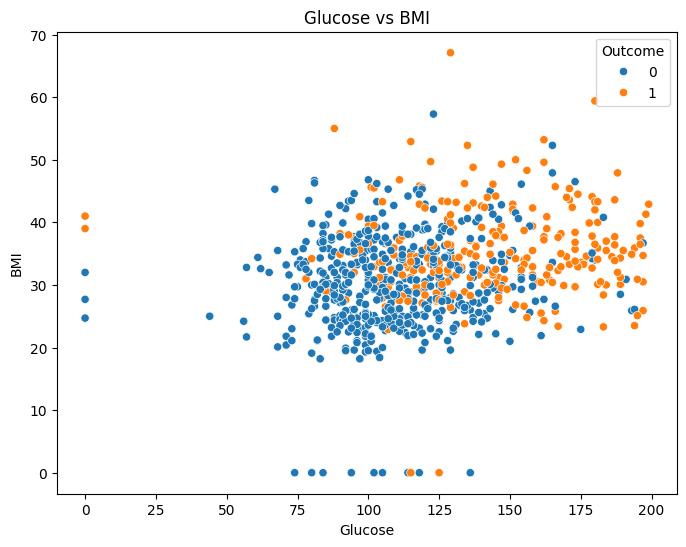

In [139]:
# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("Glucose vs BMI")
plt.show()

#DATA PREPROCESSING

In [140]:
# Replace zero values with NaN in important columns
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns:
    df[col] = df[col].replace(0, np.nan)

# Impute missing values with median
imputer = SimpleImputer(strategy='median')

df[columns] = imputer.fit_transform(df[columns])


In [141]:
# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [142]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [143]:
# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)



Training Shape: (614, 8)
Testing Shape: (154, 8)


In [144]:
# LightGBM Model
lgbm_model = LGBMClassifier(random_state=42)


In [145]:
# Train Model
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(random_state=42)

In [146]:
# Predictions
lgbm_pred = lgbm_model.predict(X_test)

In [147]:
# LightGBM Evaluation

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred)
lgbm_recall = recall_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred)

print("\nLightGBM Performance")
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)


LightGBM Performance
Accuracy : 0.7532467532467533
Precision: 0.6349206349206349
Recall   : 0.7272727272727273
F1 Score : 0.6779661016949152


In [148]:
# XGBoost Model

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

In [149]:
# Train Model
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [150]:
# Prediction
xgb_pred = xgb_model.predict(X_test)


In [151]:
# 12. XGBoost Evaluation

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("\nXGBoost Performance ")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)



XGBoost Performance 
Accuracy : 0.7142857142857143
Precision: 0.5873015873015873
Recall   : 0.6727272727272727
F1 Score : 0.6271186440677966


# 13. Cross Validation

In [152]:
# LightGBM Cross Validation
lgbm_cv = cross_val_score(lgbm_model, X_scaled, y, cv=5)

print("\nLightGBM Cross Validation Scores:")
print(lgbm_cv)
print("Average CV Score:", lgbm_cv.mean())


[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [153]:
# XGBoost Cross Validation
xgb_cv = cross_val_score(xgb_model, X_scaled, y, cv=5)

print("\nXGBoost Cross Validation Scores:")
print(xgb_cv)
print("Average CV Score:", xgb_cv.mean())



XGBoost Cross Validation Scores:
[0.74675325 0.72077922 0.72727273 0.79738562 0.73202614]
Average CV Score: 0.7448433919022154


# 14. Hyperparameter Tuning

In [154]:
# LightGBM Tuning
lgbm_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

lgbm_grid = GridSearchCV( LGBMClassifier(random_state=42), lgbm_params, cv=3)

lgbm_grid.fit(X_train, y_train)

print("\nBest Parameters for LightGBM:")
print(lgbm_grid.best_params_)


[LightGBM] [Info] Number of positive: 142, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347188 -> initscore=-0.631422
[LightGBM] [Info] Start training from score -0.631422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [155]:
# XGBoost Tuning
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

xgb_grid = GridSearchCV( XGBClassifier(eval_metric='logloss', random_state=42), xgb_params, cv=3)

xgb_grid.fit(X_train, y_train)

print("\nBest Parameters for XGBoost:")
print(xgb_grid.best_params_)



Best Parameters for XGBoost:
{'max_depth': 3, 'n_estimators': 100}


In [156]:
# 15. Comparative Analysis Table
comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [lgbm_accuracy, xgb_accuracy],
    'Precision': [lgbm_precision, xgb_precision],
    'Recall': [lgbm_recall, xgb_recall],
    'F1 Score': [lgbm_f1, xgb_f1]
})

print("\nModel Comparison:")
print(comparison)



Model Comparison:
      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.753247   0.634921  0.727273  0.677966
1   XGBoost  0.714286   0.587302  0.672727  0.627119


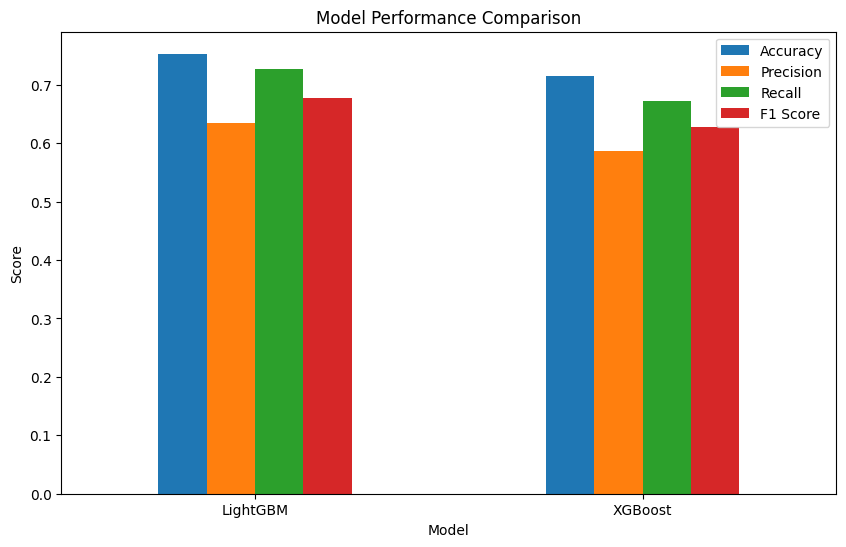

In [157]:
# 16. Visualization of Model Comparison

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


# 17. Confusion Matrix

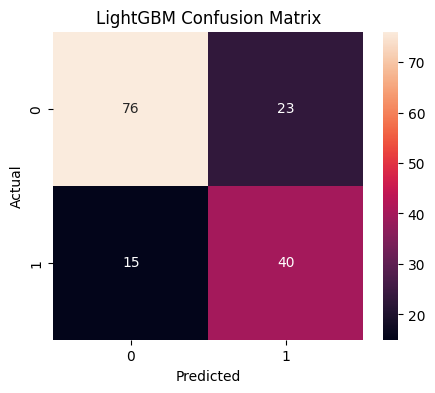

In [158]:
# LightGBM Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, lgbm_pred), annot=True, fmt='d')

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


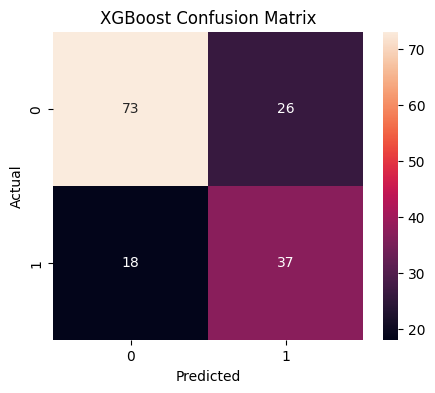

In [159]:
# XGBoost Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt='d'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [160]:
# 18. Classification Report


print("\n LightGBM Classification Report ")
print(classification_report(y_test, lgbm_pred))


print("\nXGBoost Classification Report ")
print(classification_report(y_test, xgb_pred))


 LightGBM Classification Report 
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154


XGBoost Classification Report 
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        99
           1       0.59      0.67      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



#Conclusion

LightGBM trains faster and performs efficiently on structured datasets.

XGBoost generally provides strong predictive performance and handles overfitting well.

Both algorithms performed well for diabetes prediction.

Based on accuracy, precision, recall and F1-score, the better model can be selected for deployment.